In [ ]:
# Install rdkit
from IPython.utils import io
import tqdm.notebook
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      # Install rdkit
      !pip -q install rdkit
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import rdkit
import pandas as pd
import numpy as np
from sys import argv
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem
from rdkit.Chem import rdFingerprintGenerator
from scipy.spatial.distance import pdist

In [ ]:
print(f"rdkit_version: {rdkit.__version__}")

rdkit_version: 2025.09.6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#DB_Druglike
DB_Druglike = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/smHDAC8_Prueba_all_1000_Druglike/Analisis de resultados/DB_1000_Druglike/DB_Druglike_curada.csv", sep=";")
DB_Druglike

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,Chemical,SMILES_curated
0,HD8_DL001,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NCC1=CC=CC3=C1C...,3/000000487,InChI=1S/C21H17N3O5/c25-16(22-10-12-4-2-5-14-1...,C21H17N3O5,391,1.84,5.39,-8.34,6.45,-60,O=C(C/C=C1\Cc2cccc(C(=O)O)c2N1)NCc1cccc2c1C(=O...
1,HD8_DL002,ClC1=CC=C(C=C1)COCCNC(=O)C/C=C\1/NC2C(C1)=CC=C...,3/000000194,InChI=1S/C22H25ClN2O2/c1-2-16-3-6-18-14-20(25-...,C22H25N2O2Cl,384,4.17,4.95,-7.42,6.45,-100,CCc1ccc2c(c1)N/C(=C/CC(=O)NCCOCc1ccc(Cl)cc1)C2
2,HD8_DL003,C1C(OCC2=NC=CC(=C2)C(=O)N)=CC(=CC=1)N1C(=CCNC1...,3/000000246,InChI=1S/C18H18N4O4/c19-17(23)12-4-7-21-13(8-1...,C18H17N4O4,353,0.87,4.92,-2.59,22.40,-180,NC(=O)c1ccnc(COc2cccc(N3CNCC=C3C(=O)O)c2)c1
3,HD8_DL004,C1=NC2C(C(=O)O1)=CC=CC=2NC(=O)C/C=C\1/NC2C(C1)...,3/000000066,InChI=1S/C21H19N3O3/c1-2-13-6-7-14-11-15(23-18...,C21H19N3O3,361,2.80,4.90,-6.57,6.45,-100,CCc1ccc2c(c1)N/C(=C/CC(=O)Nc1cccc3c(=O)ocnc13)C2
4,HD8_DL005,OC(=O)C1C=CC=C2C=1N/C(=C/CC(=O)NC[C@@H](CO)F)/C2,3/000000466,InChI=1S/C15H17FN2O4/c16-10(8-19)7-17-13(20)5-...,C15H17N2O4F,308,0.96,4.90,-2.45,4.94,-190,O=C(C/C=C1\Cc2cccc(C(=O)O)c2N1)NC[C@H](F)CO
...,...,...,...,...,...,...,...,...,...,...,...,...
286,HD8_DL287,OC(=O)C1=NN=C(O1)CC#CC(O)(F)F,6/000000013,"InChI=1S/C7H4F2N2O4/c8-7(9,14)3-1-2-4-10-11-5(...",C7H4N2O4F2,218,0.57,3.02,-5.31,24.20,-190,O=C(O)c1nnc(CC#CC(O)(F)F)o1
287,HD8_DL288,C(=C\CN)/C1=CC=C2C(=C1)C(=O)C=CN2,6/000000083,InChI=1S/C12H12N2O/c13-6-1-2-9-3-4-11-10(8-9)1...,C12H12N2O,200,1.51,3.01,-9.66,3.58,-80,NC/C=C/c1ccc2[nH]ccc(=O)c2c1
288,HD8_DL289,OC(=O)C/C=C/C1C=CC=C(C=1Cl)O,4/000000101,InChI=1S/C10H9ClO3/c11-10-7(3-1-5-8(10)12)4-2-...,C10H9O3Cl,212,2.27,3.01,-2.70,2.22,0,O=C(O)C/C=C/c1cccc(O)c1Cl
289,HD8_DL290,OC(=O)/C=C/CCC1=NC2=C(N1)N=CC=C2,4/000000122,InChI=1S/C11H11N3O2/c15-10(16)6-2-1-5-9-13-8-4...,C11H11N3O2,217,1.00,3.01,-10.12,4.81,-100,O=C(O)/C=C/CCc1nc2cccnc2[nH]1


In [ ]:
#DB_HighDiv
DB_HighDiv = pd.read_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/smHDAC8_Prueba_all_1000_HighDiv/Analisis_resultados/DB_1000_HighDiv/DB_HighDiv_curada.csv", sep=";")
DB_HighDiv

,ID_deNovo,SMILES,Name,InChI,Formula,MW,LogP,pKd,Structure,Synthesize,Chemical,SMILES_curated
0,HD8_HD001,OC(=S)NC1=CC=C(C(=C1)/C=C/CC1=NC(=CN1)[C@H](C)...,6/000000103,InChI=1S/C17H19N3OS2/c1-3-12-7-8-14(19-17(21)2...,C17H19N3OS2,345,3.45,4.63,-11.50,24.70,-170,C=Cc1ccc(NC(O)=S)cc1/C=C/Cc1nc([C@H](C)S)c[nH]1
1,HD8_HD002,OC1=CC=C(C(=C1)C1=CC(Cl)=CC(=C1O)Cl)CC(=O)C,3/000000076,InChI=1S/C15H12Cl2O3/c1-8(18)4-9-2-3-11(19)7-1...,C15H12O3Cl2,310,4.09,4.54,-6.86,15.00,-180,CC(=O)Cc1ccc(O)cc1-c1cc(Cl)cc(Cl)c1O
2,HD8_HD003,OC(=O)C/C=C/C1=CNC(=NC1)C1=C(Br)C=NN1,4/000000002,InChI=1S/C11H11BrN4O2/c12-8-6-15-16-10(8)11-13...,C11H11N4O2Br,311,1.27,4.50,-2.49,23.90,-160,O=C(O)C/C=C/C1=CNC(c2[nH]ncc2Br)=NC1
3,HD8_HD004,OC1=CC=C(C=C1)CC#CC1C(I)=CN=C(C=1Cl)N,3/000000134,InChI=1S/C14H10ClIN2O/c15-13-11(12(16)8-18-14(...,C14H10N2OClI,384,4.38,4.48,-5.80,16.40,0,Nc1ncc(I)c(C#CCc2ccc(O)cc2)c1Cl
4,HD8_HD005,OC1=CC=C(C=C1[C@H](CC1=CSN=C1)O)C(=C)C=C,3/000000315,InChI=1S/C15H15NO2S/c1-3-10(2)12-4-5-14(17)13(...,C15H15NO2S,273,2.62,4.34,-5.32,19.10,-150,C=CC(=C)c1ccc(O)c([C@@H](O)Cc2cnsc2)c1
...,...,...,...,...,...,...,...,...,...,...,...,...
325,HD8_HD326,O[C@](C)(C1=CCC=C1)C1=NN=C(S1)C(=O)[O-],5/000000106,"InChI=1S/C10H10N2O3S/c1-10(15,6-4-2-3-5-6)9-12...",C10H9N2O3S,237,0.27,3.01,-3.26,3.58,-190,C[C@@](O)(C1=CCC=C1)c1nnc(C(=O)O)s1
326,HD8_HD327,O[C@@H](CCl)C1=CON=C1O,2/000000005,"InChI=1S/C5H6ClNO3/c6-1-4(8)3-2-10-7-5(3)9/h2,...",C5H6NO3Cl,163,0.64,3.01,5.36,1.00,-150,Oc1nocc1[C@@H](O)CCl
327,HD8_HD328,OC1=CC=C(C=C1)C(=C)C(=O)C1=CNCS1,2/000000052,InChI=1S/C12H11NO2S/c1-8(9-2-4-10(14)5-3-9)12(...,C12H11NO2S,233,1.92,3.01,-0.41,2.22,0,C=C(C(=O)C1=CNCS1)c1ccc(O)cc1
328,HD8_HD329,S[C@H](CC(=O)C1=CC(O)=C(C=C1Cl)O)C,2/000000010,InChI=1S/C10H11ClO3S/c1-5(15)2-8(12)6-3-9(13)1...,C10H11O3SCl,246,2.47,3.00,-2.06,2.22,-190,C[C@H](S)CC(=O)c1cc(O)c(O)cc1Cl


## Commulative distribution function

In [ ]:
# SMILES list
DB_Druglike_smi = list(DB_Druglike["SMILES_curated"])
DB_HighDiv_smi = list(DB_HighDiv["SMILES_curated"])


In [ ]:
#### Functions

# Morgan2 and Morgan3
def ECFP (smi, r):
    fps = pd.DataFrame([[int(y) for y in rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=1024).GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()] for x in smi])
    SimMat = 1 - pdist(fps[[x for x in range(1024)]], metric="jaccard") # Similarity Matrix
    #print(SimMat.shape)
    #SimMat = round(np.median(SimMat), 3)
    return SimMat

# MACCS keys
def MACCSkeys_fp (smi):
    fps = pd.DataFrame([[int(y) for y in MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(x)).ToBitString()] for x in smi])
    SimMat = 1 - pdist(fps[[x for x in range(167)]], metric="jaccard") # Similarity Matrix
    #print(SimMat.shape)
    #SimMat = round(np.median(SimMat))
    return SimMat

##MACCS

In [ ]:
""" MACCS"""

# 1. Sort data
SimMatMACCS_DB_Druglike = np.sort(MACCSkeys_fp(DB_Druglike_smi))
SimMatMACCS_DB_HighDiv = np.sort(MACCSkeys_fp(DB_HighDiv_smi))



In [ ]:
# Calculate the proportional values of samples for MACCS
proportionMACCS_Druglike = 1. * np.arange(len(SimMatMACCS_DB_Druglike)) / (len(SimMatMACCS_DB_Druglike) - 1)
print(len(proportionMACCS_Druglike))

proportionMACCS_HighDiv = 1. * np.arange(len(SimMatMACCS_DB_HighDiv)) / (len(SimMatMACCS_DB_HighDiv) - 1)
print(len(proportionMACCS_HighDiv))

42195
54285


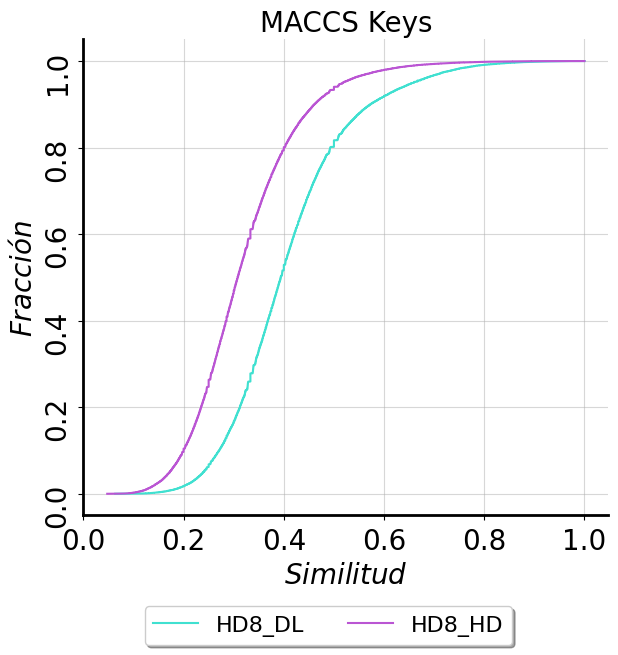

In [ ]:
# plot the sorted data:
import matplotlib.pyplot as plt
fig = plt.figure()
fig.set_size_inches(7,7)

x1 = fig.add_subplot(1,1,1)
x1.plot(SimMatMACCS_DB_Druglike, proportionMACCS_Druglike, label="HD8_DL", c="turquoise")
x1.plot(SimMatMACCS_DB_HighDiv, proportionMACCS_HighDiv, label="HD8_HD", c="mediumorchid")

x1.grid(alpha=0.5)
x1.set_xlabel('$Similitud$', fontsize=20)
x1.set_ylabel('$Fracción$', fontsize=20)
x1.set_title('MACCS Keys', fontsize=20)


x1.spines['right'].set_visible(False)
x1.spines['top'].set_visible(False)

x1.spines['left'].set_visible(True)
x1.spines['left'].set_linewidth(2.0)

x1.spines['bottom'].set_visible(True)
x1.spines['bottom'].set_linewidth(2.0)

x1.tick_params(axis='both', which='major', pad=5)
plt.xticks(rotation=0, fontsize=20)
plt.yticks(rotation=90, fontsize=20)

#fig1.legend()
fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.001), fancybox=True, shadow=True, fontsize=16)

# Avoid overlapping the legend with the axes.
fig.subplots_adjust(left=0.15, bottom=0.2)

fig.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Compounds_MACCS-Key.png", dpi=600)

Compute stat

In [ ]:
#MACCS-keys statistics

MACCS_Druglike = pd.DataFrame(SimMatMACCS_DB_Druglike, columns = ['MACCS_DB_Druglike'])
MACCS_Druglike = MACCS_Druglike.describe()

MACCS_HighDiv = pd.DataFrame(SimMatMACCS_DB_HighDiv, columns = ['MACCS_DB_HighDiv'])
MACCS_HighDiv = MACCS_HighDiv.describe()

data_MACCS = pd.concat([MACCS_Druglike, MACCS_HighDiv
                 ], axis = 1)

In [ ]:
data_MACCS = data_MACCS.round(3)
data_MACCS

,MACCS_DB_Druglike,MACCS_DB_HighDiv
count,42195.000,54285.000
mean,0.411,0.323
std,0.125,0.109
min,0.063,0.048
25%,0.328,0.250
50%,0.394,0.308
75%,0.471,0.381
max,1.000,1.000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_MACCS.to_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Analisis_MACCSKeys.csv", sep=",", index=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Morgan2

In [ ]:
"""# ECFP4"""

# 1. Sort data
SimMatECFP4_DB_Druglike = np.sort(ECFP(DB_Druglike_smi, 2))
SimMatECFP4_DB_HighDiv = np.sort(ECFP(DB_HighDiv_smi, 2))


In [ ]:
# Calculate the proportional values of samples for ECFP4 y ECFP6
proportionECFP_Druglike= 1. * np.arange(len(SimMatECFP4_DB_Druglike)) / (len(SimMatECFP4_DB_Druglike) - 1)
print(len(proportionECFP_Druglike))

proportionECFP_HighDiv = 1. * np.arange(len(SimMatECFP4_DB_HighDiv)) / (len(SimMatECFP4_DB_HighDiv) - 1)
print(len(proportionECFP_HighDiv))


42195
54285


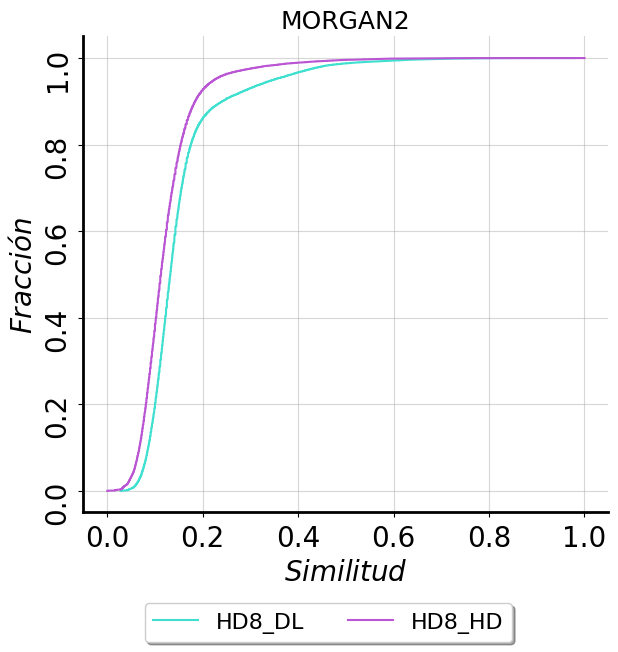

In [ ]:
# plot the sorted data:
import matplotlib.pyplot as plt
fig = plt.figure()
fig.set_size_inches(7,7)

x1 = fig.add_subplot(1,1,1)
x1.plot(SimMatECFP4_DB_Druglike, proportionECFP_Druglike, label="HD8_DL", c="turquoise")
x1.plot(SimMatECFP4_DB_HighDiv, proportionECFP_HighDiv, label="HD8_HD", c="mediumorchid")

x1.grid(alpha=0.5)
x1.set_title('MORGAN2', fontsize=18)
x1.set_xlabel('$Similitud$', fontsize=20)
x1.set_ylabel('$Fracción$', fontsize=20)


x1.spines['right'].set_visible(False)
x1.spines['top'].set_visible(False)

x1.spines['left'].set_visible(True)
x1.spines['left'].set_linewidth(2.0)

x1.spines['bottom'].set_visible(True)
x1.spines['bottom'].set_linewidth(2.0)

x1.tick_params(axis='both', which='major', pad=5)
plt.xticks(rotation=0, fontsize=20)
plt.yticks(rotation=90, fontsize=20)

#fig1.legend()
fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.001), fancybox=True, shadow=True, fontsize=16)
fig.subplots_adjust(left=0.15, bottom=0.2)

fig.savefig("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Compounds_MORGAN2.png", dpi=500)

In [ ]:
#Morgan2 statistics
morgan2_Druglike = pd.DataFrame(SimMatECFP4_DB_Druglike, columns = ['Morgan2_DB_Druglike'])
morgan2_Druglike = morgan2_Druglike.describe()

morgan2_DB_HighDiv = pd.DataFrame(SimMatECFP4_DB_HighDiv, columns = ['Morgan2_DB_HighDiv'])
morgan2_DB_HighDiv = morgan2_DB_HighDiv.describe()


data_MORGAN = pd.concat([morgan2_Druglike, morgan2_DB_HighDiv
                 ], axis = 1)

In [ ]:
data_MORGAN = data_MORGAN.round(3)
data_MORGAN

,Morgan2_DB_Druglike,Morgan2_DB_HighDiv
count,42195.000,54285.000
mean,0.154,0.125
std,0.089,0.065
min,0.028,0.000
25%,0.106,0.087
50%,0.132,0.113
75%,0.164,0.145
max,0.979,1.000


In [ ]:
data_MORGAN.to_csv("/content/drive/MyDrive/FBDD_Denovo_VRC/Caracterizacion_denovo/Analisis_MORGAN.csv", sep=",", index=True)